In [10]:
import pandas as pd
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load dataset
df = pd.read_csv("analysis_dataset.csv")

# Filter only winning projects
df_winners = df[df['is_winner'] == True]

# Text columns to consider
text_columns = [
    'inspiration', 'what_it_does', 'how_we_built_it', 'challenges',
    'accomplishments', 'what_we_learned', 'what_is_next', 
    'tech_stack', 'github_summary'
]

# Combine all text into a single string
combined_text = ' '.join(
    df_winners[col].dropna().astype(str).str.cat(sep=' ')
    for col in text_columns
)

# Clean text: lowercase, remove non-alphabetic characters
clean_text = re.sub(r'[^a-zA-Z\s]', '', combined_text.lower())

# Split into words
words = clean_text.split()

# Remove stopwords
filtered_words = [word for word in words if word not in stop_words]

# Count most common words
word_counts = Counter(filtered_words)

# Show top 20 most common words
print(word_counts.most_common(20))


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gauurab/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('project', 5759), ('data', 3826), ('application', 2892), ('users', 2581), ('user', 2385), ('using', 2381), ('development', 2324), ('also', 2175), ('python', 2156), ('web', 2006), ('backend', 1955), ('like', 1794), ('repository', 1642), ('time', 1598), ('frontend', 1591), ('learning', 1570), ('api', 1565), ('deployment', 1553), ('use', 1550), ('ai', 1504)]


In [11]:
def get_word_set(df_subset):
    """Get a set of all words in the subset, after cleaning and removing stopwords"""
    combined_text = ' '.join(
        df_subset[col].dropna().astype(str).str.cat(sep=' ')
        for col in text_columns
    )
    clean_text = re.sub(r'[^a-zA-Z\s]', '', combined_text.lower())
    words = clean_text.split()
    filtered_words = set(word for word in words if word not in stop_words)
    return filtered_words

# Words in winning projects
winning_words = get_word_set(df[df['is_winner'] == True])

# Words in losing projects
losing_words = get_word_set(df[df['is_winner'] == False])

# Words unique to winning projects
unique_winning_words = winning_words - losing_words

# Sort by frequency in winning projects
from collections import Counter

# Flatten winning words to count frequency
combined_winning_text = ' '.join(
    df[df['is_winner'] == True][col].dropna().astype(str).str.cat(sep=' ')
    for col in text_columns
)
clean_winning_text = re.sub(r'[^a-zA-Z\s]', '', combined_winning_text.lower())
winning_words_list = [w for w in clean_winning_text.split() if w not in stop_words]

# Count frequency only for unique winning words
word_counts = Counter([w for w in winning_words_list if w in unique_winning_words])

# Show top 20 unique winning words
print(word_counts.most_common(20))


[('aptos', 58), ('birdblog', 56), ('rec', 53), ('locl', 52), ('quantum', 51), ('scout', 48), ('sustainify', 48), ('hedera', 48), ('trustfile', 44), ('mediguide', 32), ('aptocheck', 32), ('splatting', 32), ('faceconnect', 30), ('sagewell', 28), ('formfixer', 28), ('linguify', 28), ('instapc', 28), ('plateo', 26), ('aros', 26), ('hecklerai', 24)]


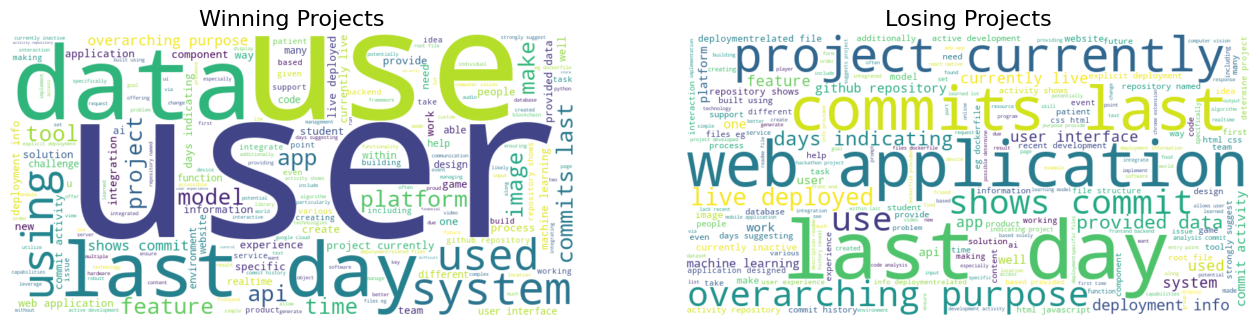

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt



def get_clean_text(df_subset):
    """Combine text columns, clean text, remove stopwords"""
    combined_text = ' '.join(
        df_subset[col].dropna().astype(str).str.cat(sep=' ')
        for col in text_columns
    )
    clean_text = re.sub(r'[^a-zA-Z\s]', '', combined_text.lower())
    words = [word for word in clean_text.split() if word not in stop_words]
    return ' '.join(words)

# Clean text for winners and losers
text_winners = get_clean_text(df[df['is_winner'] == True])
text_losers = get_clean_text(df[df['is_winner'] == False])

# Generate word clouds
wc_winner = WordCloud(width=800, height=400, background_color='white').generate(text_winners)
wc_loser = WordCloud(width=800, height=400, background_color='white').generate(text_losers)

# Plot side by side
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wc_winner, interpolation='bilinear')
plt.axis('off')
plt.title('Winning Projects', fontsize=16)

plt.subplot(1, 2, 2)
plt.imshow(wc_loser, interpolation='bilinear')
plt.axis('off')
plt.title('Losing Projects', fontsize=16)

plt.show()

In [19]:
def keyword_project_percentage(df_subset, keywords):
    """Compute percentage of projects that mention each keyword"""
    total_projects = len(df_subset)
    percentages = {}
    
    for keyword in keywords:
        keyword_lower = keyword.lower()
        # Count projects containing the keyword at least once
        count = df_subset.apply(
            lambda row: any(
                re.search(r'\b' + re.escape(keyword_lower) + r'\b', str(row[col]).lower())
                for col in text_columns if pd.notna(row[col])
            ),
            axis=1
        ).sum()
        
        percentages[keyword] = (count / total_projects) * 100 if total_projects > 0 else 0
    return percentages

keywords = ['AI', 'machine learning', 'deep learning' , 'deployment', 'quantum']

# Percentages in winners
winner_percent = keyword_project_percentage(df[df['is_winner'] == True], keywords)

# Percentages in losers
loser_percent = keyword_project_percentage(df[df['is_winner'] == False], keywords)

print("Percentage of Winning Projects mentioning keywords:", winner_percent)
print("Percentage of Losing Projects mentioning keywords:", loser_percent)


Percentage of Winning Projects mentioning keywords: {'AI': 45.479204339963836, 'machine learning': 24.68354430379747, 'deep learning': 2.3508137432188065, 'deployment': 90.6871609403255, 'quantum': 0.27124773960216997}
Percentage of Losing Projects mentioning keywords: {'AI': 39.17270301181853, 'machine learning': 18.661837590545176, 'deep learning': 3.0499428135722457, 'deployment': 92.58482653450247, 'quantum': 0.0}
